# Part0 공통기반 — 실습 과제 모범 답안
> KOREATECH 제조AI 교육과정 v1.6.15 | 교수자 배포용

In [1]:
import numpy as np
import pandas as pd
import matplotlib
matplotlib.rcParams['font.family'] = 'AppleGothic'
matplotlib.rcParams['axes.unicode_minus'] = False
import matplotlib.pyplot as plt

# 합성 제조 데이터 생성
np.random.seed(42)
n = 1000
df = pd.DataFrame({
    'temperature':   np.random.normal(65, 8, n).clip(40, 100),
    'spindle_speed': np.random.normal(3000, 400, n).clip(1000, 5000),
    'tool_wear':     np.abs(np.random.normal(0, 1, n) * 80),
    'vibration_x':   np.random.exponential(0.5, n),
    'defect':        (np.random.rand(n) > 0.85).astype(int),
})
print(f"데이터 shape: {df.shape}")
df.describe()


데이터 shape: (1000, 5)


,temperature,spindle_speed,tool_wear,vibration_x,defect
count,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000
mean,65.155587,3028.334495,62.802238,0.483685,0.156000
std,7.830682,398.981751,47.350985,0.487957,0.363037
min,40.000000,1823.844546,0.016565,0.000015,0.000000
25%,59.819278,2757.503324,26.229195,0.140307,0.000000
50%,65.202405,3025.230853,52.063453,0.330387,0.000000
75%,70.183551,3291.552871,89.047736,0.655090,0.000000
max,95.821852,4277.243027,314.099017,3.048277,1.000000


## 📒 노트북 01 — KAMP 데이터 탐색·EDA
### 과제 A (필수): spindle_speed 히스토그램

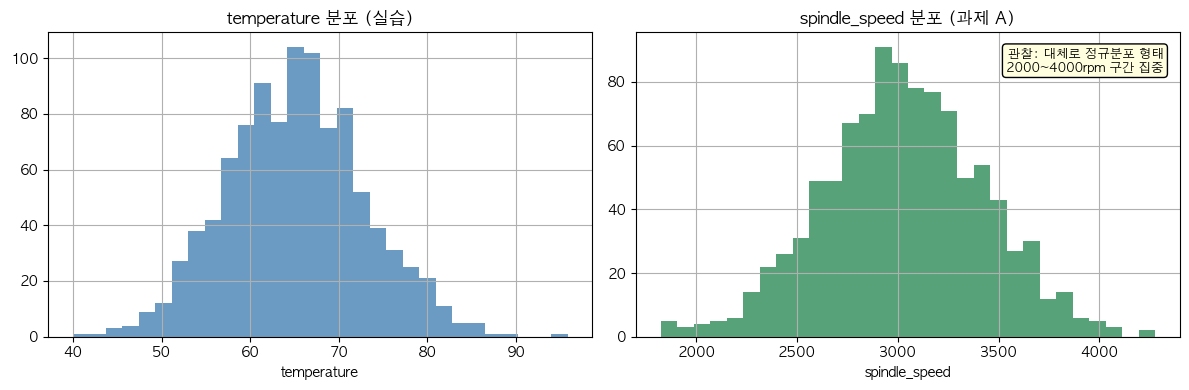

관찰: spindle_speed는 종 모양 분포. 실습(temperature)과 유사하지만 더 넓은 범위.


In [2]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
df['temperature'].hist(bins=30, ax=axes[0], color='steelblue', alpha=0.8)
axes[0].set_title('temperature 분포 (실습)')
axes[0].set_xlabel('temperature')

df['spindle_speed'].hist(bins=30, ax=axes[1], color='seagreen', alpha=0.8)
axes[1].set_title('spindle_speed 분포 (과제 A)')
axes[1].set_xlabel('spindle_speed')
axes[1].text(0.97, 0.95, '관찰: 대체로 정규분포 형태\n2000~4000rpm 구간 집중',
             transform=axes[1].transAxes, ha='right', va='top',
             fontsize=9, bbox=dict(boxstyle='round', fc='lightyellow'))
plt.tight_layout()
plt.show()
print("관찰: spindle_speed는 종 모양 분포. 실습(temperature)과 유사하지만 더 넓은 범위.")


### 과제 B (필수): mean-max 차이 최대 컬럼

mean-max 차이 최대 컬럼: spindle_speed  (차이: 1248.91)


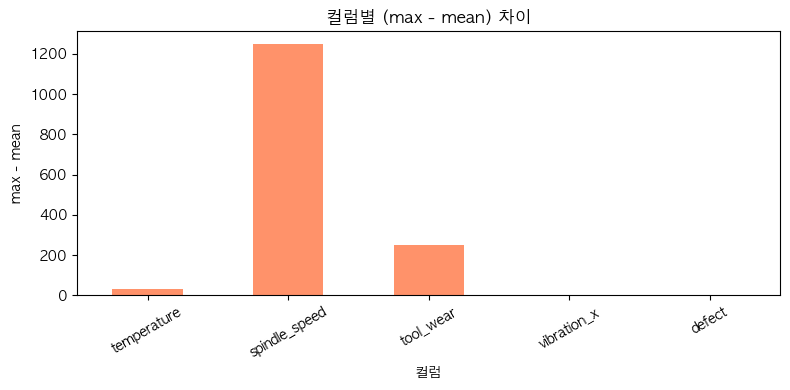

In [3]:
diff = df.describe().loc['max'] - df.describe().loc['mean']
max_col = diff.idxmax()
print(f"mean-max 차이 최대 컬럼: {max_col}  (차이: {diff[max_col]:.2f})")

fig, ax = plt.subplots(figsize=(8, 4))
diff.plot(kind='bar', ax=ax, color='coral', alpha=0.85)
ax.set_title('컬럼별 (max - mean) 차이', fontsize=12)
ax.set_xlabel('컬럼')
ax.set_ylabel('max - mean')
ax.tick_params(axis='x', rotation=30)
plt.tight_layout()
plt.show()


### 과제 C (심화): 정상 vs 불량 평균 온도

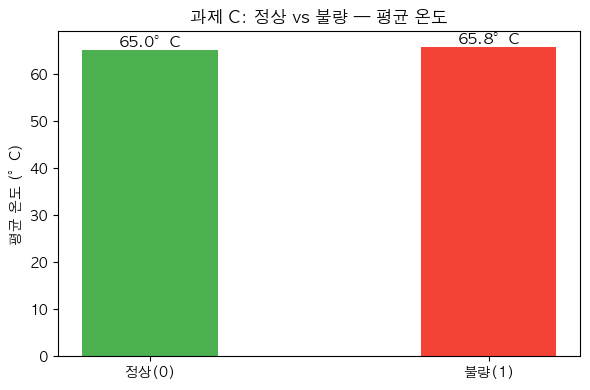

정상 평균: 65.03°C  /  불량 평균: 65.81°C
→ 불량 시 온도가 0.78°C 더 높음


In [4]:
grp = df.groupby('defect')['temperature'].mean()
fig, ax = plt.subplots(figsize=(6, 4))
bars = ax.bar(['정상(0)', '불량(1)'], grp.values, color=['#4caf50','#f44336'], width=0.4)
ax.bar_label(bars, fmt='%.1f°C', fontsize=11)
ax.set_title('과제 C: 정상 vs 불량 — 평균 온도', fontsize=12)
ax.set_ylabel('평균 온도 (°C)')
plt.tight_layout()
plt.show()
print(f"정상 평균: {grp[0]:.2f}°C  /  불량 평균: {grp[1]:.2f}°C")
print(f"→ 불량 시 온도가 {grp[1]-grp[0]:.2f}°C 더 높음")
